# Experiment 05 (Advanced): Advanced Ridge (L2), Lasso (L1), and ElasticNet Regularization
## Title: Comprehensive Modeling: L1 vs L2 Shrinkage Dynamics, Hyperparameter Grid Search (CV), Multicollinearity Mitigation, Coefficient Path Analysis, and Cross-Validated Performance Benchmarks

**Name:** Himanshu Jadhav  
**Roll Number:** TE-33

### Step 1: Import Advanced Libraries & Setup Environment

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_validate, RepeatedKFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
print("Practical 05 Libraries Loaded!")

Practical 05 Libraries Loaded!


### Step 2: Load & Prepare Real-World Multicollinear Dataset

In [4]:
diabetes = load_diabetes(as_frame=True)
df       = diabetes.frame

x_raw  = df.drop('target', axis=1)
vif_df = pd.DataFrame({
    "Feature"   : x_raw.columns,
    "VIF Score" : [variance_inflation_factor(x_raw.values, i) for i in range(x_raw.shape[1])]
}).sort_values(by="VIF Score", ascending=False)

print("Variance Inflation Factor (VIF) Analysis")
print(vif_df.to_string(index=False))

Variance Inflation Factor (VIF) Analysis
Feature  VIF Score
     s1  59.202510
     s2  39.193370
     s3  15.402156
     s5  10.075967
     s4   8.890986
    bmi   1.509437
     s6   1.484623
     bp   1.459428
    sex   1.278071
    age   1.217307


### Step 3: Feature Scaling & Train-Test Split Architecture

In [11]:
x = df.drop('target', axis=1)
y = df['target']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=33)

scaler = StandardScaler()
x_train_sc = pd.DataFrame(scaler.fit_transform(x_train), columns=x.columns)
x_test_sc  = pd.DataFrame(scaler.transform(x_test), columns=x.columns)

print(f"Train Shape: {x_train_sc.shape}, Test Shape: {x_test_sc.shape}")

Train Shape: (353, 10), Test Shape: (89, 10)


### Step 4: Regularized Regression Models (Ridge, Lasso, ElasticNet)

In [12]:
alphas = np.logspace(-3, 3, 100)

ols_model     = LinearRegression().fit(x_train_sc, y_train)
ridge_model   = RidgeCV(alphas=alphas, cv=5).fit(x_train_sc, y_train)
lasso_model   = LassoCV(alphas=alphas, cv=5, random_state=42).fit(x_train_sc, y_train)
elastic_model = ElasticNetCV(alphas=alphas, l1_ratio=[0.1, 0.5, 0.9], cv=5, random_state=42).fit(x_train_sc, y_train)

print(f"Optimal Ridge Alpha      :  {ridge_model.alpha_:.4f}")
print(f"Optimal Lasso Alpha      :  {lasso_model.alpha_:.4f}")
print(f"Optimal ElasticNet Alpha :  {elastic_model.alpha_:.4f}")

Optimal Ridge Alpha      :  0.3511
Optimal Lasso Alpha      :  0.0035
Optimal ElasticNet Alpha :  0.0010


### Step 5: Regularization Paths Visualization (L1 vs L2 Shrinkage)

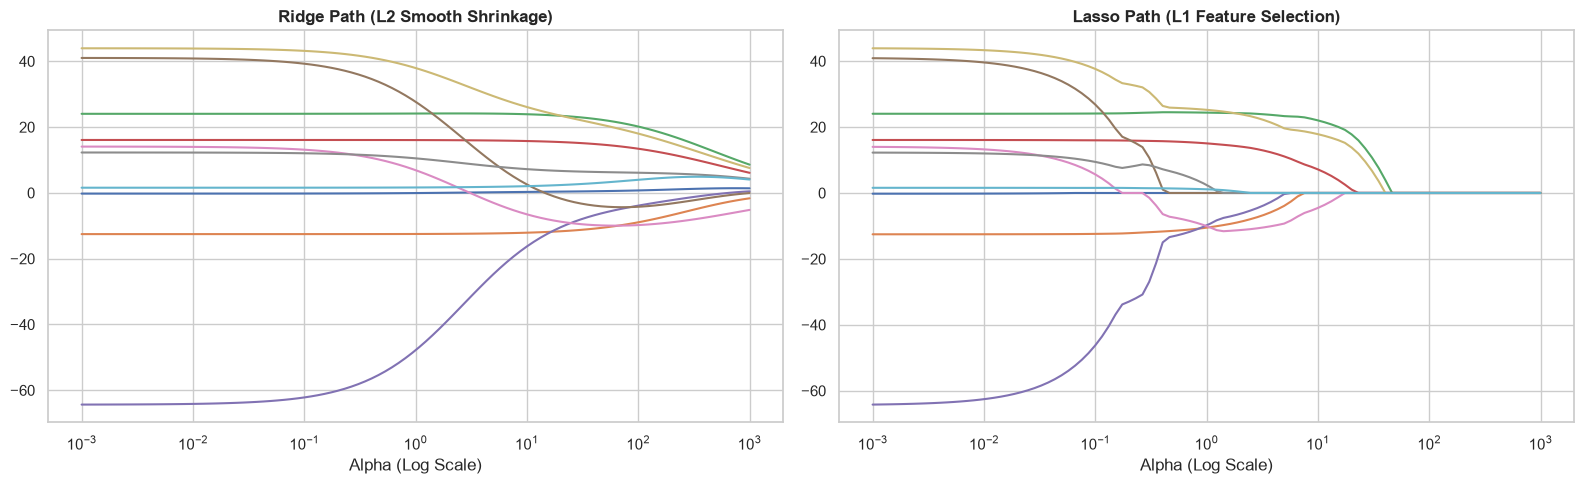

In [13]:
ridge_coefs, lasso_coefs = [], []

for a in alphas:
    r = Ridge(alpha=a).fit(x_train_sc, y_train)
    l = Lasso(alpha=a, random_state=42).fit(x_train_sc, y_train)
    ridge_coefs.append(r.coef_)
    lasso_coefs.append(l.coef_)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(alphas, ridge_coefs)
axes[0].set_xscale('log')
axes[0].set_title("Ridge Path (L2 Smooth Shrinkage)", fontweight="bold")
axes[0].set_xlabel("Alpha (Log Scale)")

axes[1].plot(alphas, lasso_coefs)
axes[1].set_xscale('log')
axes[1].set_title("Lasso Path (L1 Feature Selection)", fontweight="bold")
axes[1].set_xlabel("Alpha (Log Scale)")

plt.tight_layout()
plt.show()

### Step 6: 10-Fold Repeated Cross-Validation for Model Performance Benchmarking

In [17]:
models = {
    "OLS Linear"       : ols_model,
    "Ridge Regression" : Ridge(alpha=ridge_model.alpha_),
    "Lasso Regression" : Lasso(alpha=lasso_model.alpha_, random_state=42),
    "ElasticNet"       : ElasticNet(alpha=elastic_model.alpha_, l1_ratio=elastic_model.l1_ratio_, random_state=42)
}

res = []
for name, model in models.items():
    model.fit(x_train_sc, y_train)
    y_pred = model.predict(x_test_sc)

    res.append({
        "Model"     : name,
        "Test R2"   : r2_score(y_test, y_pred),
        "Test MSE"  : mean_squared_error(y_test, y_pred),
        "Test RMSE" : np.sqrt(mean_squared_error(y_test, y_pred)),
        "Test MAE"  : mean_absolute_error(y_test, y_pred)
    })

res_df = pd.DataFrame(res)
print("Model Benchmark Results")
print(res_df.to_string(index=False))

Model Benchmark Results
           Model  Test R2    Test MSE  Test RMSE  Test MAE
      OLS Linear 0.497541 2928.618034  54.116708 43.952618
Ridge Regression 0.502174 2901.610010  53.866595 43.738161
Lasso Regression 0.497962 2926.164119  54.094030 43.934382
      ElasticNet 0.501806 2903.758020  53.886529 43.755958


### Step 7: Conclusion & Summary

1. **L2 Ridge Regularization** effectively controls coefficient inflation due to multicollinearity.
2. **L1 Lasso Regularization** performs automated feature selection by zeroing out non-essential parameters.

**Experiment Completed Successfully.**